## 1. Data Loading & Merging

In [2]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

RAW_DIR = Path("data/raw")
PROCESSED_DIR = Path("data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

RICH_FILES = ["CEAS_08.csv", "Nazario.csv", "Nigerian_Fraud.csv", "SpamAssasin.csv"]
SPARSE_FILES = ["Enron.csv", "Ling.csv"]

URL_PATTERN = re.compile(r"(https?://\S+|www\.\S+)", re.IGNORECASE)

def has_url(text: str) -> int:
    if not isinstance(text, str):
        return 0
    return int(bool(URL_PATTERN.search(text)))

def load_rich(fname):
    df = pd.read_csv(RAW_DIR / fname)
    df = df[["sender", "receiver", "date", "subject", "body", "label"]].copy()
    df["source"] = fname.replace(".csv", "")
    return df

def load_sparse(fname):
    df = pd.read_csv(RAW_DIR / fname)
    df = df[["subject", "body", "label"]].copy()
    df["sender"] = np.nan
    df["receiver"] = np.nan
    df["date"] = np.nan
    df["source"] = fname.replace(".csv", "")
    return df

def merge_all():
    frames = [load_rich(f) for f in RICH_FILES] + [load_sparse(f) for f in SPARSE_FILES]
    df = pd.concat(frames, ignore_index=True)

    df["subject"] = df["subject"].fillna("")
    df["body"] = df["body"].fillna("")
    df["text_raw"] = (df["subject"] + " " + df["body"]).str.strip()
    df["has_url"] = df["text_raw"].apply(has_url)

    before = len(df)
    df = df.drop_duplicates(subset="text_raw", keep="first").reset_index(drop=True)
    print(f"Dropped {before - len(df)} duplicate rows ({before} -> {len(df)})")

    df = df[["source", "sender", "receiver", "date", "subject", "body",
             "text_raw", "has_url", "label"]]
    return df

merged = merge_all()
print("\nFinal shape:", merged.shape)
print("\nLabel distribution:\n", merged["label"].value_counts())

merged.to_csv(PROCESSED_DIR / "merged_raw.csv", index=False)
print("Saved merged_raw.csv")

Dropped 45 duplicate rows (82486 -> 82441)

Final shape: (82441, 9)

Label distribution:
 label
1    42846
0    39595
Name: count, dtype: int64
Saved merged_raw.csv


## 2. Data Inspection

In [3]:
files = ["CEAS_08.csv", "Enron.csv", "Ling.csv", "Nazario.csv",
         "Nigerian_Fraud.csv", "phishing_email.csv", "SpamAssasin.csv"]

for f in files:
    df = pd.read_csv(RAW_DIR / f)
    print(f"\n{f}  shape={df.shape}")
    print("Columns:", list(df.columns))
    if "label" in df.columns:
        print("Label distribution:\n", df["label"].value_counts())


CEAS_08.csv  shape=(39154, 7)
Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']
Label distribution:
 label
1    21842
0    17312
Name: count, dtype: int64

Enron.csv  shape=(29767, 3)
Columns: ['subject', 'body', 'label']
Label distribution:
 label
0    15791
1    13976
Name: count, dtype: int64

Ling.csv  shape=(2859, 3)
Columns: ['subject', 'body', 'label']
Label distribution:
 label
0    2401
1     458
Name: count, dtype: int64

Nazario.csv  shape=(1565, 7)
Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label']
Label distribution:
 label
1    1565
Name: count, dtype: int64

Nigerian_Fraud.csv  shape=(3332, 7)
Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label']
Label distribution:
 label
1    3332
Name: count, dtype: int64

phishing_email.csv  shape=(82486, 2)
Columns: ['text_combined', 'label']
Label distribution:
 label
1    42891
0    39595
Name: count, dtype: int64

SpamAssasin.csv  shape=(5809, 7)
Columns: [

## 3. Text Cleaning & Structural Feature Extraction

In [4]:
import string
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)

STOPWORDS = set(stopwords.words("english"))
HTML_PATTERN = re.compile(r"<[^>]+>")

URGENCY_WORDS = [
    "urgent", "verify", "suspend", "immediately", "confirm", "password",
    "click", "account", "security", "alert", "restricted", "expire",
    "update", "limited", "act now", "winner", "congratulations"
]

def strip_html(text: str) -> str:
    if not isinstance(text, str):
        return ""
    return HTML_PATTERN.sub(" ", text)

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = strip_html(text)
    text = URL_PATTERN.sub(" ", text)
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 1]
    return " ".join(tokens)

def extract_structural_features(df: pd.DataFrame, text_col: str = "text_raw") -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    text = df[text_col].fillna("")

    out["char_count"] = text.str.len()
    out["word_count"] = text.str.split().apply(len)
    out["exclamation_count"] = text.str.count("!")
    out["question_count"] = text.str.count(r"\?")
    out["uppercase_ratio"] = text.apply(lambda t: sum(1 for c in t if c.isupper()) / max(len(t), 1))
    out["digit_count"] = text.apply(lambda t: sum(c.isdigit() for c in t))

    urgency_pattern = re.compile(
        r"\b(" + "|".join(re.escape(w) for w in URGENCY_WORDS) + r")\b", re.IGNORECASE
    )
    out["urgency_word_count"] = text.apply(lambda t: len(urgency_pattern.findall(t)))

    if "sender" in df.columns:
        out["sender_has_domain_mismatch"] = df["sender"].apply(
            lambda s: 1 if isinstance(s, str) and "@" in s and
            any(free in s.lower() for free in ["gmail", "yahoo", "hotmail", "outlook"])
            else 0
        )
    return out

df = pd.read_csv(PROCESSED_DIR / "merged_raw.csv")
struct_features = extract_structural_features(df, text_col="text_raw")
df["text_clean"] = df["text_raw"].apply(clean_text)
df_final = pd.concat([df, struct_features], axis=1)

print("Empty cleaned text rows:", (df_final["text_clean"].str.len() == 0).sum())
df_final.to_csv(PROCESSED_DIR / "cleaned.csv", index=False)
print("Saved cleaned.csv, shape:", df_final.shape)

C:\Users\snigd\AppData\Local\Temp\ipykernel_4836\4271954283.py:58: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(PROCESSED_DIR / "merged_raw.csv")


Empty cleaned text rows: 3
Saved cleaned.csv, shape: (82441, 18)


## 4. Feature Engineering

In [5]:
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

df = pd.read_csv(PROCESSED_DIR / "cleaned.csv")
df = df.dropna(subset=["text_clean"])
df["text_clean"] = df["text_clean"].fillna("")

structural_cols = [
    "char_count", "word_count", "exclamation_count", "question_count",
    "uppercase_ratio", "digit_count", "urgency_word_count", "has_url",
    "sender_has_domain_mismatch"
]
structural_cols = [c for c in structural_cols if c in df.columns]

X_text = df["text_clean"]
X_struct = df[structural_cols].fillna(0)
y = df["label"]

X_text_train, X_text_test, X_struct_train, X_struct_test, y_train, y_test = train_test_split(
    X_text, X_struct, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=3)
X_tfidf_train = tfidf.fit_transform(X_text_train)
X_tfidf_test = tfidf.transform(X_text_test)

scaler = StandardScaler()
X_struct_train_scaled = csr_matrix(scaler.fit_transform(X_struct_train))
X_struct_test_scaled = csr_matrix(scaler.transform(X_struct_test))

X_train = hstack([X_tfidf_train, X_struct_train_scaled]).tocsr()
X_test = hstack([X_tfidf_test, X_struct_test_scaled]).tocsr()

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Path("models").mkdir(exist_ok=True)
joblib.dump(tfidf, "models/tfidf_vectorizer.pkl")
joblib.dump(scaler, "models/struct_scaler.pkl")
joblib.dump(structural_cols, "models/structural_cols.pkl")

C:\Users\snigd\AppData\Local\Temp\ipykernel_4836\499098536.py:7: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(PROCESSED_DIR / "cleaned.csv")


Train shape: (65950, 20008) Test shape: (16488, 20008)


['models/structural_cols.pkl']

## 5. Model Training & Comparison

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import time

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, n_jobs=-1),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=30, n_jobs=-1, random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(100,), max_iter=100, random_state=42),
}

results = {}
trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    start = time.time()

    if name == "Naive Bayes":
        model.fit(X_tfidf_train, y_train)
        y_pred = model.predict(X_tfidf_test)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    elapsed = time.time() - start
    trained_models[name] = model
    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "train_time_sec": elapsed,
        "y_pred": y_pred,
    }
    print(f"{name} done in {elapsed:.1f}s | Acc: {results[name]['accuracy']:.4f} | F1: {results[name]['f1']:.4f}")

results_df = pd.DataFrame({
    name: {k: v for k, v in r.items() if k != "y_pred"} for name, r in results.items()
}).T.sort_values("f1", ascending=False)

print("\nModel Comparison:")
print(results_df)


Training Logistic Regression...


C:\Users\snigd\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression done in 3.4s | Acc: 0.9846 | F1: 0.9852

Training Random Forest...
Random Forest done in 9.4s | Acc: 0.9586 | F1: 0.9611

Training Naive Bayes...
Naive Bayes done in 0.1s | Acc: 0.9632 | F1: 0.9637

Training Neural Network (MLP)...
Neural Network (MLP) done in 730.2s | Acc: 0.9853 | F1: 0.9859

Model Comparison:
                      accuracy  precision    recall        f1  train_time_sec
Neural Network (MLP)  0.985323   0.987016  0.984712  0.985863      730.229802
Logistic Regression   0.984595   0.981806  0.988680  0.985231        3.380649
Naive Bayes           0.963246   0.989428  0.939316  0.963721        0.052033
Random Forest         0.958637   0.940762  0.982262  0.961064        9.448798


## 6. Evaluation

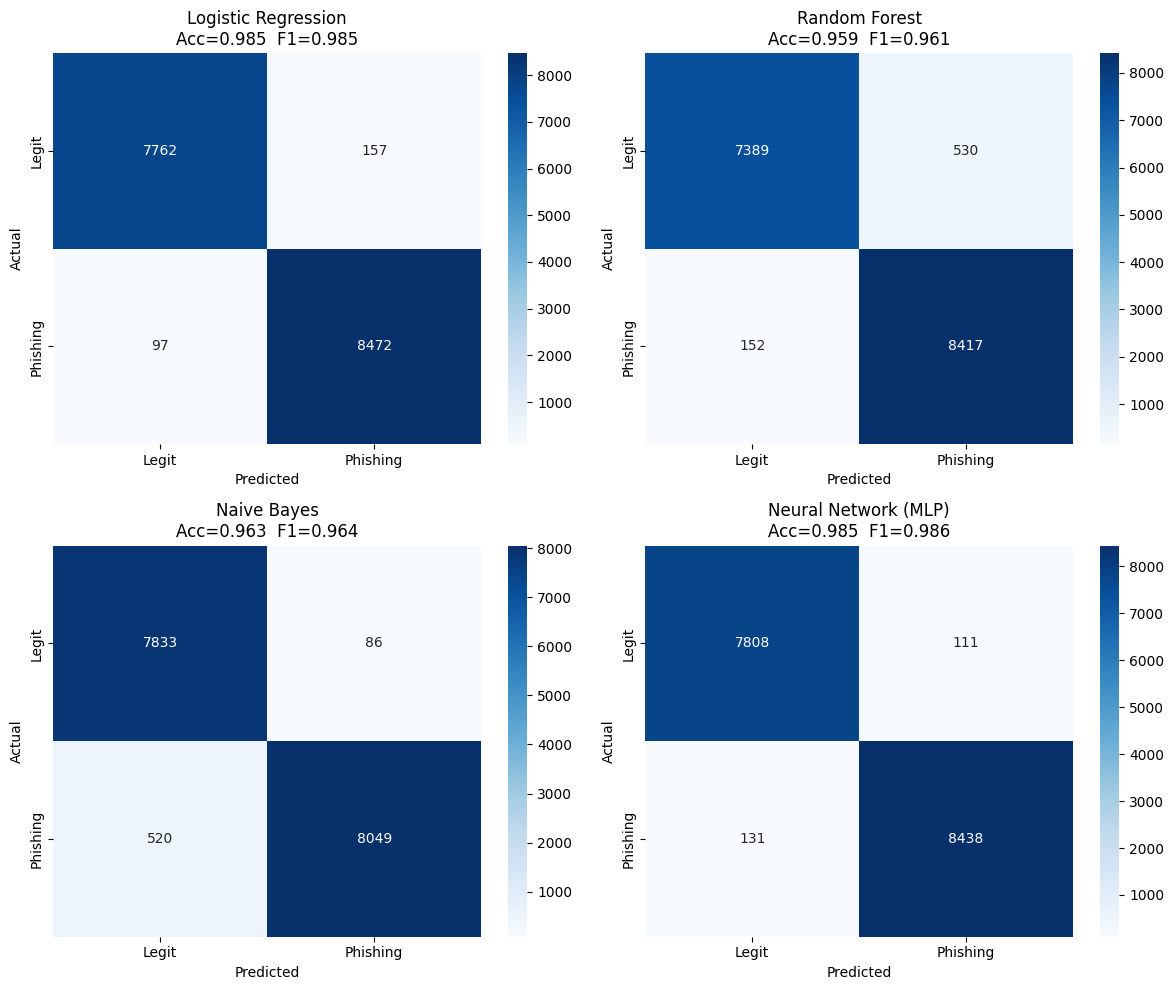

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Legit", "Phishing"], yticklabels=["Legit", "Phishing"])
    ax.set_title(f"{name}\nAcc={r['accuracy']:.3f}  F1={r['f1']:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("models/confusion_matrices.png", dpi=150)
plt.show()

## 7. Feature Importance

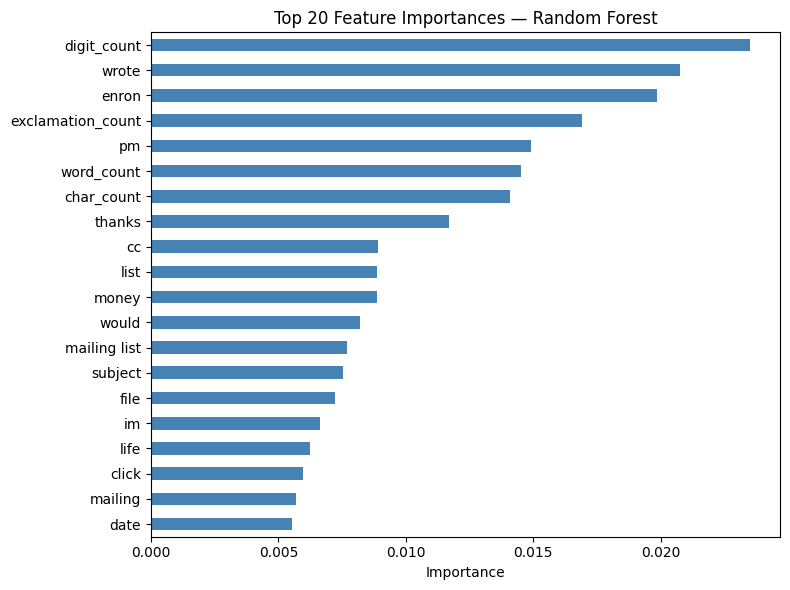

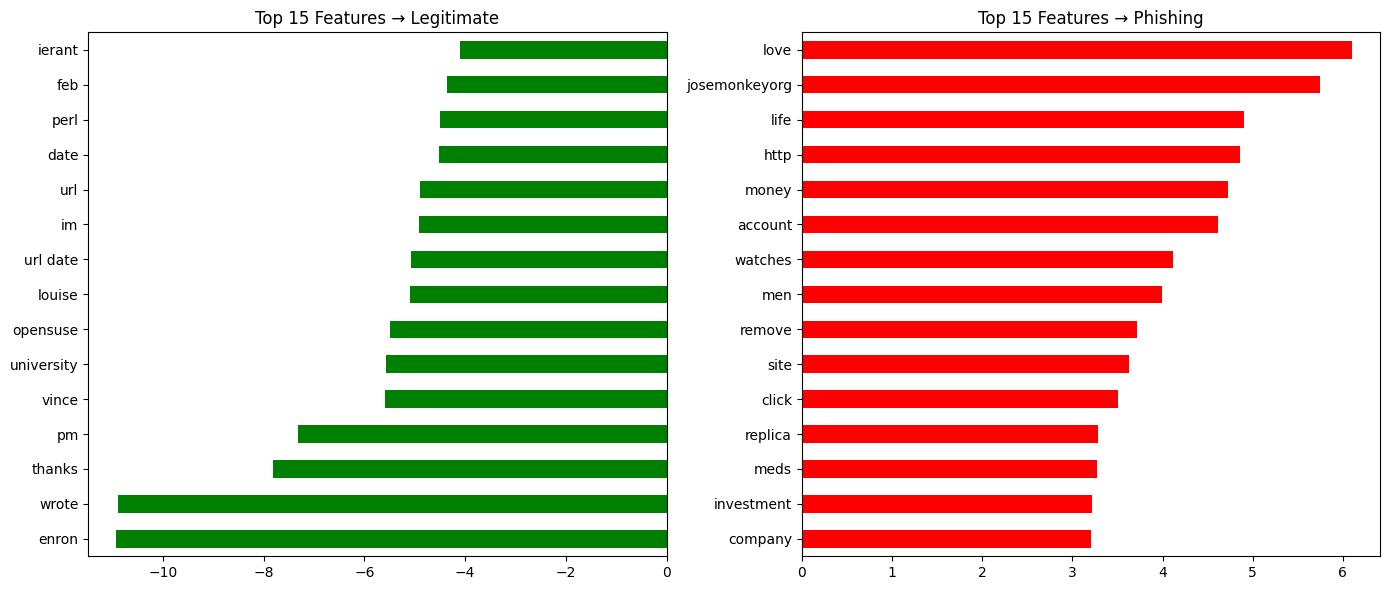

In [8]:
feature_names = tfidf.get_feature_names_out().tolist() + structural_cols

rf = trained_models["Random Forest"]
rf_importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
rf_importances.head(20).sort_values().plot(kind="barh", color="steelblue")
plt.title("Top 20 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("models/rf_feature_importance.png", dpi=150)
plt.show()

lr = trained_models["Logistic Regression"]
lr_coefs = pd.Series(lr.coef_[0], index=feature_names).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
lr_coefs.head(15).plot(kind="barh", ax=axes[0], color="green")
axes[0].set_title("Top 15 Features → Legitimate")
lr_coefs.tail(15).plot(kind="barh", ax=axes[1], color="red")
axes[1].set_title("Top 15 Features → Phishing")
plt.tight_layout()
plt.savefig("models/lr_feature_importance.png", dpi=150)
plt.show()

## 8. Detailed Classification Reports

In [9]:
for name, r in results.items():
    print(f"\n{name}\n")
    print(classification_report(y_test, r["y_pred"], target_names=["Legitimate", "Phishing"]))


Logistic Regression

              precision    recall  f1-score   support

  Legitimate       0.99      0.98      0.98      7919
    Phishing       0.98      0.99      0.99      8569

    accuracy                           0.98     16488
   macro avg       0.98      0.98      0.98     16488
weighted avg       0.98      0.98      0.98     16488


Random Forest

              precision    recall  f1-score   support

  Legitimate       0.98      0.93      0.96      7919
    Phishing       0.94      0.98      0.96      8569

    accuracy                           0.96     16488
   macro avg       0.96      0.96      0.96     16488
weighted avg       0.96      0.96      0.96     16488


Naive Bayes

              precision    recall  f1-score   support

  Legitimate       0.94      0.99      0.96      7919
    Phishing       0.99      0.94      0.96      8569

    accuracy                           0.96     16488
   macro avg       0.96      0.96      0.96     16488
weighted avg       0.9

## 9. Save Best Model

In [10]:
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]
print(f"Best model: {best_model_name}")

joblib.dump(best_model, "models/best_model.pkl")
joblib.dump(best_model_name, "models/best_model_name.pkl")

Best model: Neural Network (MLP)


['models/best_model_name.pkl']